# MAX30102 Log Analysis (RAW LOGGER)

Notebook này kiểm tra nhanh luồng dữ liệu từ firmware logger:
- Đọc file log CSV từ ESP32
- Parse và làm sạch dữ liệu
- Plot tín hiệu IR/RED/power theo thời gian
- Cắt window 8s, stride 2s
- Trích feature theo cùng style với `ppg_dalia.ipynb`
- Đánh giá phân bố feature và độ ổn định sơ bộ

In [1]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])
print("✅ Packages ready")

✅ Packages ready


In [2]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, welch, find_peaks

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.11.9
CWD: c:\ml\kaggle-ml-basics


In [3]:
# Quét toàn bộ log theo format: profile_<name>_<good|bad>_<idx>.csv (recursive)
LOG_DIR = Path(r"C:/ml/kaggle-ml-basics/log")
TARGET_PROFILES = ["25sps_low", "50sps_med", "100sps_med"]

assert LOG_DIR.exists(), f"Không tìm thấy thư mục log: {LOG_DIR}"

FILE_RE = re.compile(r"^profile_(?P<profile_name>.+?)_(?P<condition>good|bad)_(?P<run_idx>\d+)\.csv$")

records = []
for fp in sorted(LOG_DIR.rglob("profile_*_*.csv")):
    parent_path = str(fp.parent).lower()
    if "deprecated" in parent_path:
        continue

    m = FILE_RE.match(fp.name)
    if m is None:
        continue

    profile_name = m.group("profile_name")
    if profile_name not in TARGET_PROFILES:
        continue

    records.append({
        "file_path": fp,
        "file_name": fp.name,
        "profile_name": profile_name,
        "condition": m.group("condition"),
        "run_idx": int(m.group("run_idx")),
        "group_dir": fp.parent.name,
    })

experiment_df = pd.DataFrame(records).sort_values(["profile_name", "condition", "run_idx"]).reset_index(drop=True)
assert len(experiment_df) > 0, "Không tìm thấy file đúng format trong thư mục log"

print("Found experiment files:", len(experiment_df))
display(experiment_df)

expected_runs = experiment_df.groupby(["profile_name", "condition"]).size().rename("n_runs").reset_index()
print("\nRun count per profile-condition:")
display(expected_runs)

Found experiment files: 18


,file_path,file_name,profile_name,condition,run_idx,group_dir
0,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0_100sps_med
1,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_bad_02.csv,100sps_med,bad,2,0_100sps_med
2,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_bad_03.csv,100sps_med,bad,3,0_100sps_med
3,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_good_01.csv,100sps_med,good,1,0_100sps_med
4,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_good_02.csv,100sps_med,good,2,0_100sps_med
5,C:\ml\kaggle-ml-basics\log\0_100sps_med\profil...,profile_100sps_med_good_03.csv,100sps_med,good,3,0_100sps_med
6,C:\ml\kaggle-ml-basics\log\1_25sps_low\profile...,profile_25sps_low_bad_01.csv,25sps_low,bad,1,1_25sps_low
7,C:\ml\kaggle-ml-basics\log\1_25sps_low\profile...,profile_25sps_low_bad_02.csv,25sps_low,bad,2,1_25sps_low
8,C:\ml\kaggle-ml-basics\log\1_25sps_low\profile...,profile_25sps_low_bad_03.csv,25sps_low,bad,3,1_25sps_low
9,C:\ml\kaggle-ml-basics\log\1_25sps_low\profile...,profile_25sps_low_good_01.csv,25sps_low,good,1,1_25sps_low



Run count per profile-condition:


,profile_name,condition,n_runs
0,100sps_med,bad,3
1,100sps_med,good,3
2,25sps_low,bad,3
3,25sps_low,good,3
4,50sps_med,bad,3
5,50sps_med,good,3


In [4]:
CSV_RE = re.compile(

    r"^(?P<timestamp_ms>\d+),(?P<profile_id>\d+),(?P<red>\d+),(?P<ir>\d+),(?P<bus_v>-?\d+(?:\.\d+)?),(?P<current_ma>-?\d+(?:\.\d+)?),(?P<power_mw>-?\d+(?:\.\d+)?)$"

)



def parse_logger_file(path: Path):

    rows = []

    total_lines = 0

    matched_lines = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:

        for line in f:

            total_lines += 1

            s = line.strip()

            if not s or s.startswith("I (") or "SYS_DEMO:" in s:

                continue

            m = CSV_RE.match(s)

            if m is None:

                continue

            matched_lines += 1

            rows.append({

                "timestamp_ms": int(m.group("timestamp_ms")),

                "profile_id": int(m.group("profile_id")),

                "red": int(m.group("red")),

                "ir": int(m.group("ir")),

                "bus_v": float(m.group("bus_v")),

                "current_ma": float(m.group("current_ma")),

                "power_mw": float(m.group("power_mw")),

            })



    df = pd.DataFrame(rows)

    if len(df) == 0:

        raise ValueError(f"Không parse được dòng CSV nào từ file: {path}")



    df = df.sort_values("timestamp_ms").drop_duplicates(subset=["timestamp_ms"], keep="last").reset_index(drop=True)

    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0

    df["dt_s"] = df["time_s"].diff().fillna(0.0)

    return df, total_lines, matched_lines



all_raw_parts = []

file_stats = []



for _, row in experiment_df.iterrows():

    df_one, total_lines, matched_lines = parse_logger_file(Path(row["file_path"]))

    dt = df_one["dt_s"].values

    dt = dt[dt > 1e-6]

    fs_est = 1.0 / np.median(dt) if len(dt) else np.nan



    df_one["file_name"] = row["file_name"]

    df_one["profile_name"] = row["profile_name"]

    df_one["condition"] = row["condition"]

    df_one["run_idx"] = row["run_idx"]

    all_raw_parts.append(df_one)



    file_stats.append({

        "file_name": row["file_name"],

        "profile_name": row["profile_name"],

        "condition": row["condition"],

        "run_idx": row["run_idx"],

        "rows_raw": len(df_one),

        "duration_s": float(df_one["time_s"].iloc[-1]),

        "fs_est_hz": float(fs_est) if np.isfinite(fs_est) else np.nan,

        "matched_csv_rows": matched_lines,

        "total_lines": total_lines,

        "profile_ids_in_file": ",".join(map(str, sorted(df_one["profile_id"].unique().tolist()))),

    })



raw_df = pd.concat(all_raw_parts, ignore_index=True)

file_stats_df = pd.DataFrame(file_stats).sort_values(["profile_name", "condition", "run_idx"]).reset_index(drop=True)



print("Total rows across all files:", len(raw_df))

display(file_stats_df)

display(raw_df.head())

Total rows across all files: 27268


,file_name,profile_name,condition,run_idx,rows_raw,duration_s,fs_est_hz,matched_csv_rows,total_lines,profile_ids_in_file
0,profile_100sps_med_bad_01.csv,100sps_med,bad,1,1527,61.052,25.0,1527,1527,0
1,profile_100sps_med_bad_02.csv,100sps_med,bad,2,1514,60.568,25.0,1515,1515,0
2,profile_100sps_med_bad_03.csv,100sps_med,bad,3,1513,60.484,25.0,1513,1513,0
3,profile_100sps_med_good_01.csv,100sps_med,good,1,1513,60.492,25.0,1513,1513,0
4,profile_100sps_med_good_02.csv,100sps_med,good,2,1515,60.471,25.0,1515,1515,0
5,profile_100sps_med_good_03.csv,100sps_med,good,3,1514,60.548,25.0,1514,1514,0
6,profile_25sps_low_bad_01.csv,25sps_low,bad,1,1514,60.535,25.0,1514,1514,1
7,profile_25sps_low_bad_02.csv,25sps_low,bad,2,1514,60.489,25.0,1514,1514,1
8,profile_25sps_low_bad_03.csv,25sps_low,bad,3,1511,60.287,25.0,1511,1511,1
9,profile_25sps_low_good_01.csv,25sps_low,good,1,1517,60.654,25.0,1517,1527,1


,timestamp_ms,profile_id,red,ir,bus_v,current_ma,power_mw,time_s,dt_s,file_name,profile_name,condition,run_idx
0,192,0,83082,82985,3.048,4.4,13.411,0.000,0.000,profile_100sps_med_bad_01.csv,100sps_med,bad,1
1,231,0,107425,113960,3.048,4.4,13.411,0.039,0.039,profile_100sps_med_bad_01.csv,100sps_med,bad,1
2,271,0,107473,114614,3.188,14.1,44.951,0.079,0.040,profile_100sps_med_bad_01.csv,100sps_med,bad,1
3,311,0,108320,116492,3.188,14.1,44.951,0.119,0.040,profile_100sps_med_bad_01.csv,100sps_med,bad,1
4,351,0,109845,119521,3.188,14.1,44.951,0.159,0.040,profile_100sps_med_bad_01.csv,100sps_med,bad,1


=== Per-file sampling summary ===


,file_name,profile_name,condition,rows_raw,duration_s,fs_est_hz,profile_ids_in_file
0,profile_100sps_med_bad_01.csv,100sps_med,bad,1527,61.052,25.0,0
1,profile_100sps_med_bad_02.csv,100sps_med,bad,1514,60.568,25.0,0
2,profile_100sps_med_bad_03.csv,100sps_med,bad,1513,60.484,25.0,0
3,profile_100sps_med_good_01.csv,100sps_med,good,1513,60.492,25.0,0
4,profile_100sps_med_good_02.csv,100sps_med,good,1515,60.471,25.0,0
5,profile_100sps_med_good_03.csv,100sps_med,good,1514,60.548,25.0,0
6,profile_25sps_low_bad_01.csv,25sps_low,bad,1514,60.535,25.0,1
7,profile_25sps_low_bad_02.csv,25sps_low,bad,1514,60.489,25.0,1
8,profile_25sps_low_bad_03.csv,25sps_low,bad,1511,60.287,25.0,1
9,profile_25sps_low_good_01.csv,25sps_low,good,1517,60.654,25.0,1



=== Profile-condition summary ===


,profile_name,condition,n_files,duration_mean_s,fs_mean_hz,fs_std_hz
0,100sps_med,bad,3,60.701333,25.0,0.0
1,100sps_med,good,3,60.503667,25.0,0.0
2,25sps_low,bad,3,60.437000,25.0,0.0
3,25sps_low,good,3,60.618667,25.0,0.0
4,50sps_med,bad,3,60.515333,25.0,0.0
5,50sps_med,good,3,60.270333,25.0,0.0


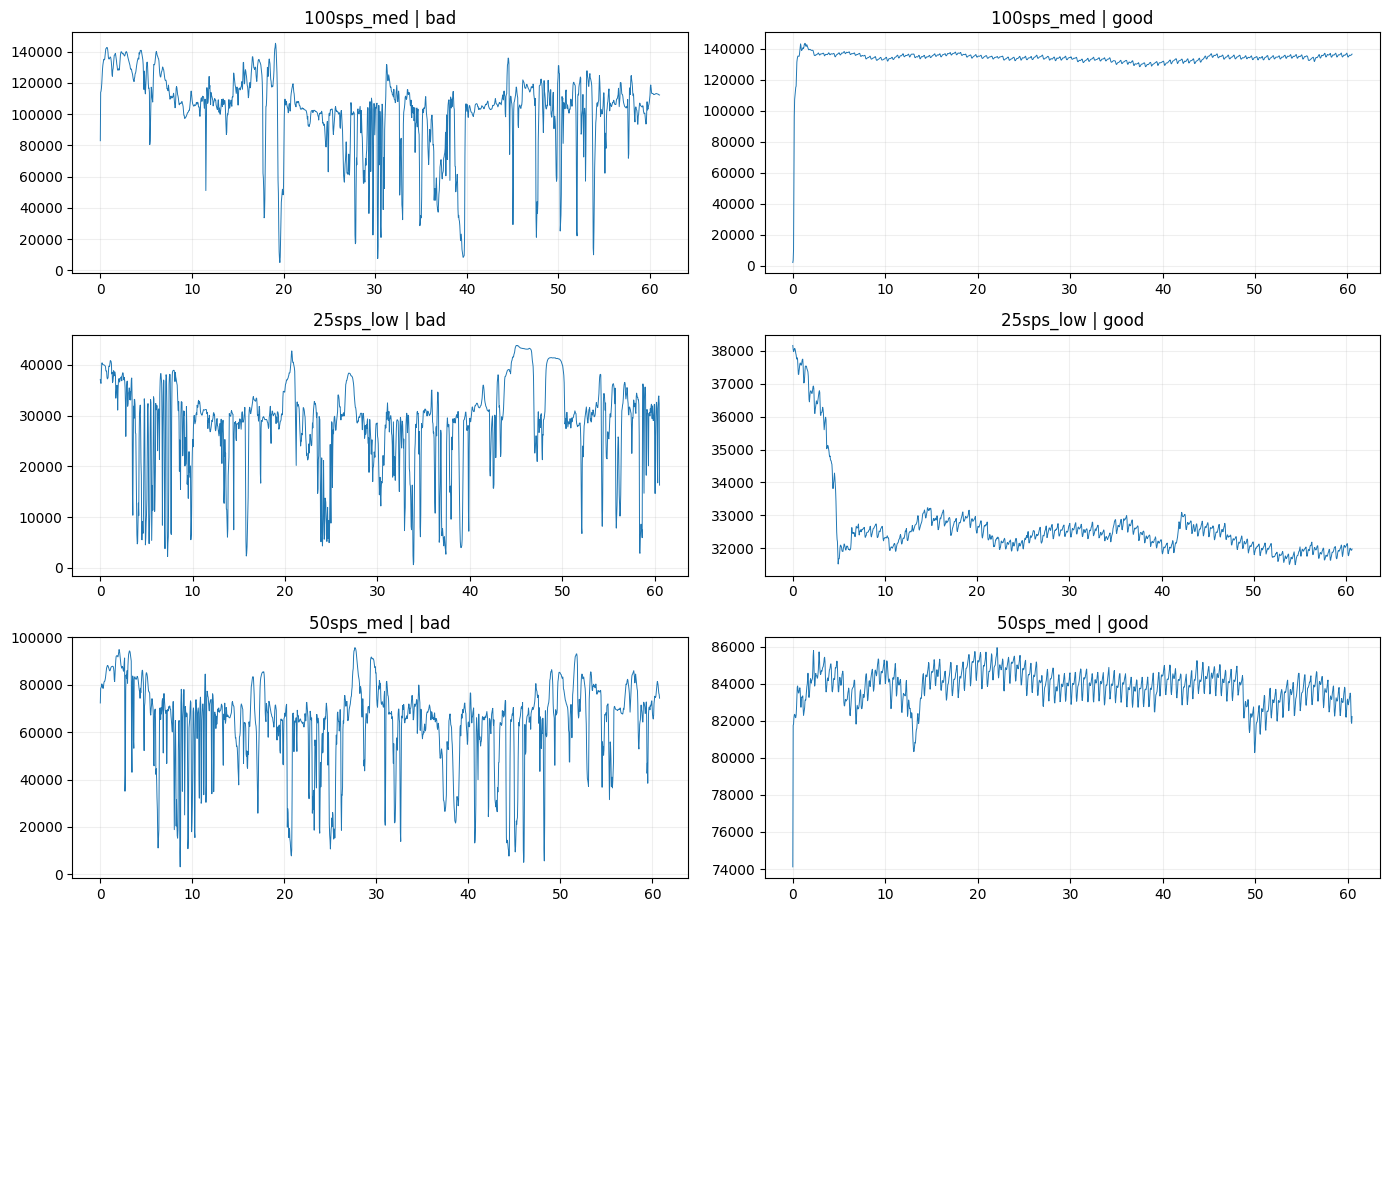

In [5]:
print("=== Per-file sampling summary ===")

display(file_stats_df[["file_name", "profile_name", "condition", "rows_raw", "duration_s", "fs_est_hz", "profile_ids_in_file"]])



summary_by_profile = file_stats_df.groupby(["profile_name", "condition"]).agg(

    n_files=("file_name", "count"),

    duration_mean_s=("duration_s", "mean"),

    fs_mean_hz=("fs_est_hz", "mean"),

    fs_std_hz=("fs_est_hz", "std"),

).reset_index()



print("\n=== Profile-condition summary ===")

display(summary_by_profile)



# Plot quick-look cho 1 file đại diện mỗi profile x condition

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)

axes = axes.ravel()

pairs = file_stats_df[["profile_name", "condition"]].drop_duplicates().values.tolist()



for idx, (profile_name, condition) in enumerate(pairs[:len(axes)]):

    rep_file = file_stats_df[(file_stats_df["profile_name"] == profile_name) & (file_stats_df["condition"] == condition)].iloc[0]["file_name"]

    df_rep = raw_df[raw_df["file_name"] == rep_file]

    ax = axes[idx]

    ax.plot(df_rep["time_s"], df_rep["ir"], linewidth=0.7)

    ax.set_title(f"{profile_name} | {condition}")

    ax.grid(alpha=0.2)



for j in range(len(pairs), len(axes)):

    axes[j].axis("off")



plt.tight_layout()

plt.show()

In [6]:
def safe_nan_to_num(x):
    x = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def detrend_signal(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return x.copy()
    return signal.detrend(x).astype(np.float32)

def butter_bandpass_filter(x, fs, lowcut=0.7, highcut=5.0, order=3):
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    low = max(0.001, lowcut / nyq)
    high = min(0.99, highcut / nyq)
    if low >= high:
        return x.copy()
    b, a = butter(order, [low, high], btype="band")
    if len(x) < max(len(a), len(b)) * 3:
        return x.copy()
    return filtfilt(b, a, x).astype(np.float32)

def robust_zscore(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < 1e-8:
        scale = np.std(x)
    if scale < 1e-8:
        scale = 1.0
    return ((x - med) / scale).astype(np.float32)

def preprocess_ppg(sig, fs):
    x_raw = safe_nan_to_num(sig)
    x_dt = detrend_signal(x_raw)
    x_bp = butter_bandpass_filter(x_dt, fs=fs, lowcut=0.7, highcut=5.0, order=3)
    x_norm = robust_zscore(x_bp)
    return x_raw, x_dt, x_bp, x_norm

def normalized_autocorr(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    denom = np.sum(x * x)
    if denom < 1e-8:
        return np.zeros(len(x), dtype=np.float32)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(x)-1:] / denom
    return ac.astype(np.float32)

def spectral_entropy_from_psd(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd = np.maximum(psd, 1e-12)
    psd = psd / np.sum(psd)
    return float(-np.sum(psd * np.log(psd)) / np.log(len(psd)))

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    integrator = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrator(psd[mask], freqs[mask]))

def extract_ppg_features(sig_raw, fs):
    _, _, _, x = preprocess_ppg(sig_raw, fs)
    n = len(x)
    feats = {}

    dx = np.diff(x)
    feats["mean"] = float(np.mean(x))
    feats["std"] = float(np.std(x))
    feats["ptp"] = float(np.ptp(x))
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["abs_mean"] = float(np.mean(np.abs(x)))
    feats["slope_abs_mean"] = float(np.mean(np.abs(dx))) if len(dx) > 0 else 0.0

    min_distance = max(1, int(fs * 0.33))
    prominence = max(0.05, 0.15 * np.std(x))
    peaks, peak_props = find_peaks(x, distance=min_distance, prominence=prominence)

    feats["n_peaks"] = float(len(peaks))
    feats["peak_rate_per_sec"] = float(len(peaks) / (n / fs)) if n > 0 else 0.0

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        hr_inst = 60.0 / np.clip(ibi, 1e-6, None)
        feats["hr_est_mean"] = float(np.mean(hr_inst))
        feats["hr_est_std"] = float(np.std(hr_inst))
    else:
        feats["hr_est_mean"] = 0.0
        feats["hr_est_std"] = 0.0

    if len(peaks) > 0 and "prominences" in peak_props:
        feats["peak_prom_mean"] = float(np.mean(peak_props["prominences"]))
    else:
        feats["peak_prom_mean"] = 0.0

    ac = normalized_autocorr(x)
    lag_min = int(fs * 60 / 180)
    lag_max = min(int(fs * 60 / 40), len(ac) - 1)

    if lag_max > lag_min:
        ac_band = ac[lag_min:lag_max + 1]
        best_idx = np.argmax(ac_band)
        best_lag = lag_min + best_idx
        feats["ac_best"] = float(ac[best_lag])
        feats["ac_best_hr"] = float(60.0 / (best_lag / fs))
    else:
        feats["ac_best"] = 0.0
        feats["ac_best_hr"] = 0.0

    nperseg = min(256, len(x))
    if nperseg >= 32:
        freqs, psd = welch(x, fs=fs, nperseg=nperseg)
        psd = np.maximum(psd, 1e-12)
        total_power = bandpower(freqs, psd, 0.0, min(8.0, fs / 2))
        hr_power = bandpower(freqs, psd, 0.7, 3.5)
        feats["psd_hr_ratio"] = float(hr_power / (total_power + 1e-8))
        feats["spectral_entropy"] = spectral_entropy_from_psd(psd)

        hr_mask = (freqs >= 0.7) & (freqs <= 3.5)
        if np.sum(hr_mask) > 0:
            f_hr = freqs[hr_mask]
            p_hr = psd[hr_mask]
            feats["dom_bpm_hr_band"] = float(f_hr[np.argmax(p_hr)] * 60.0)
        else:
            feats["dom_bpm_hr_band"] = 0.0
    else:
        feats["psd_hr_ratio"] = 0.0
        feats["spectral_entropy"] = 0.0
        feats["dom_bpm_hr_band"] = 0.0

    for k, v in list(feats.items()):
        if isinstance(v, (float, np.floating)) and (np.isnan(v) or np.isinf(v)):
            feats[k] = 0.0

    return feats

In [7]:
WIN_SEC = 8.0

STRIDE_SEC = 2.0

TRANSIENT_DROP_SEC = 3.0

TIMING_P95_FACTOR = 2.5



rows = []

skipped_timing = 0



for file_name, df_file in raw_df.groupby("file_name"):

    df_file = df_file.sort_values("timestamp_ms").reset_index(drop=True)



    # Bỏ transient đầu phiên đo

    df_work = df_file[df_file["time_s"] >= TRANSIENT_DROP_SEC].copy().reset_index(drop=True)

    if len(df_work) < 100:

        continue



    dt = df_work["timestamp_ms"].diff().fillna(0).values / 1000.0

    dt = dt[dt > 1e-6]

    fs_file = 1.0 / np.median(dt) if len(dt) else np.nan

    if not np.isfinite(fs_file) or fs_file <= 1.0:

        fs_file = 25.0



    win = int(WIN_SEC * fs_file)

    step = int(STRIDE_SEC * fs_file)

    if win <= 0 or step <= 0 or len(df_work) < win:

        continue



    sig_ir = df_work["ir"].astype(np.float32).values

    sig_red = df_work["red"].astype(np.float32).values



    for start in range(0, len(sig_ir) - win + 1, step):

        end = start + win

        seg_ir = sig_ir[start:end]

        seg_red = sig_red[start:end]

        seg_df = df_work.iloc[start:end]



        seg_dt = seg_df["timestamp_ms"].diff().fillna(0).values / 1000.0

        valid_dt = seg_dt[seg_dt > 1e-6]

        timing_ok = True

        if len(valid_dt) > 0:

            timing_ok = np.percentile(valid_dt, 95) < TIMING_P95_FACTOR * np.median(valid_dt)

        if not timing_ok:

            skipped_timing += 1

            continue



        feats = extract_ppg_features(seg_ir, fs=fs_file)

        item = {

            "file_name": file_name,

            "profile_name": str(seg_df["profile_name"].iloc[0]),

            "condition": str(seg_df["condition"].iloc[0]),

            "run_idx": int(seg_df["run_idx"].iloc[0]),

            "profile_id_mode": int(seg_df["profile_id"].mode().iloc[0]),

            "fs_file": float(fs_file),

            "window_start_s": float(seg_df["time_s"].iloc[0]),

            "window_end_s": float(seg_df["time_s"].iloc[-1]),

            "ir_raw_mean": float(np.mean(seg_ir)),

            "ir_raw_std": float(np.std(seg_ir)),

            "ir_raw_ptp": float(np.ptp(seg_ir)),

            "red_raw_std": float(np.std(seg_red)),

            "power_mw_mean": float(seg_df["power_mw"].mean()),

            "power_mw_std": float(seg_df["power_mw"].std(ddof=0)),

        }

        item.update(feats)

        rows.append(item)



feature_df = pd.DataFrame(rows)

print("feature_df shape:", feature_df.shape)

print("skipped windows due to timing gate:", skipped_timing)

display(feature_df.head())

assert len(feature_df) > 10, "Số window quá ít sau filtering; cần log dài hơn hoặc nới điều kiện timing gate."

feature_df shape: (451, 30)
skipped windows due to timing gate: 0


,file_name,profile_name,condition,run_idx,profile_id_mode,fs_file,window_start_s,window_end_s,ir_raw_mean,ir_raw_std,...,n_peaks,peak_rate_per_sec,hr_est_mean,hr_est_std,peak_prom_mean,ac_best,ac_best_hr,psd_hr_ratio,spectral_entropy,dom_bpm_hr_band
0,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0,25.0,3.039,11.001,117685.882812,12946.779297,...,12.0,1.500,102.064847,34.376413,3.101766,0.172067,57.692308,0.806305,0.653061,60.0
1,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0,25.0,5.040,13.001,112038.562500,11734.057617,...,13.0,1.625,104.099080,39.913095,2.950282,0.168263,51.724138,0.823435,0.665349,82.5
2,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0,25.0,7.040,15.001,107865.859375,7788.469727,...,15.0,1.875,125.151424,40.510194,2.579724,0.125104,88.235294,0.745758,0.721868,82.5
3,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0,25.0,9.040,17.002,110505.578125,10519.078125,...,14.0,1.750,124.738864,34.571083,2.360534,0.192791,48.387097,0.775153,0.682433,82.5
4,profile_100sps_med_bad_01.csv,100sps_med,bad,1,0,25.0,11.041,19.002,112984.921875,16886.615234,...,12.0,1.500,105.871969,30.529494,2.995179,0.364454,65.217391,0.849289,0.606738,60.0


In [8]:
# Difficulty proxy giống notebook PPG-DaLiA
feature_df["difficulty_score"] = (
    0.4 * feature_df["hr_est_std"].fillna(0.0) +
    0.3 * (1.0 - np.clip(feature_df["ac_best"].fillna(0.0), 0.0, 1.0)) +
    0.3 * feature_df["spectral_entropy"].fillna(0.0)
)

mn = feature_df["difficulty_score"].min()
mx = feature_df["difficulty_score"].max()
if mx > mn:
    feature_df["difficulty_score_norm"] = (feature_df["difficulty_score"] - mn) / (mx - mn)
else:
    feature_df["difficulty_score_norm"] = 0.0

stability_stats = []
for c in ["ac_best", "hr_est_std", "spectral_entropy", "difficulty_score_norm", "power_mw_mean"]:
    m = float(feature_df[c].mean())
    s = float(feature_df[c].std(ddof=0))
    cv = float(s / (abs(m) + 1e-8))
    stability_stats.append({"feature": c, "mean": m, "std": s, "cv": cv})

stability_df = pd.DataFrame(stability_stats).sort_values("cv")
display(stability_df)

,feature,mean,std,cv
2,spectral_entropy,0.561967,0.099823,0.177632
1,hr_est_std,35.754892,9.235891,0.258311
4,power_mw_mean,16.307477,4.417725,0.270902
3,difficulty_score_norm,0.611033,0.168236,0.275330
0,ac_best,0.467804,0.255159,0.545440


,gate,pass_ratio
0,ir_dynamic,0.889135
1,peak_rate,1.000000
2,ac,0.929047
3,entropy,1.000000
4,all_pass,0.818182


=== Profile-condition quality map ===


,profile_name,condition,windows,quality_pass_ratio,power_mw_mean,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,76,0.842105,19.060457,0.604189,0.212097,127240.197368
1,100sps_med,good,75,1.000000,19.612429,0.538545,0.719870,5078.440000
2,25sps_low,bad,75,0.853333,13.711025,0.650646,0.235361,36204.853333
3,25sps_low,good,75,0.333333,17.526769,0.653504,0.673621,700.853333
4,50sps_med,bad,75,0.880000,13.462131,0.691279,0.253756,82160.226667
5,50sps_med,good,75,1.000000,14.435346,0.528127,0.715526,2856.693333


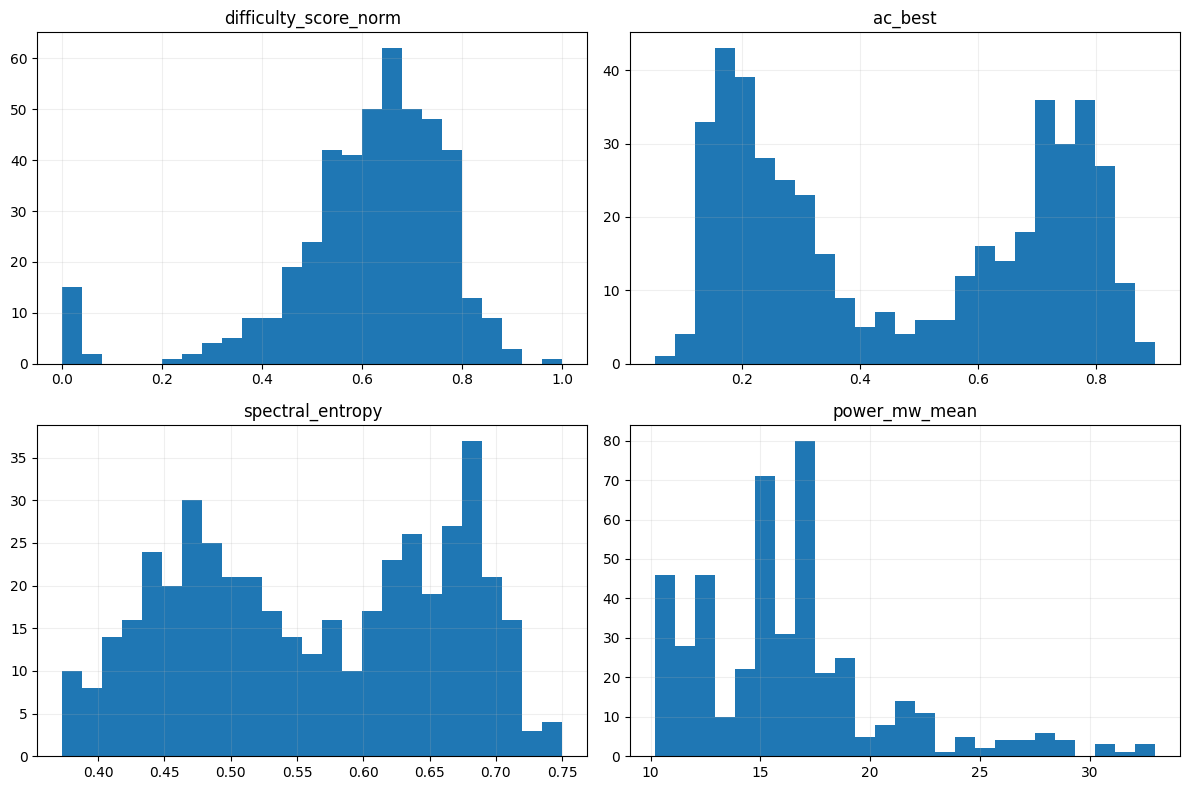

In [9]:
# Simple quality gates cho log thật (mục tiêu: compatibility/stability, không phải accuracy)

quality_df = feature_df.copy()

quality_df["gate_ir_dynamic"] = quality_df["ir_raw_ptp"] > 800

quality_df["gate_peak_rate"] = quality_df["peak_rate_per_sec"].between(40/60, 180/60)

quality_df["gate_ac"] = quality_df["ac_best"] > 0.15

quality_df["gate_entropy"] = quality_df["spectral_entropy"] < 0.95



quality_df["quality_pass"] = (

    quality_df["gate_ir_dynamic"] &

    quality_df["gate_peak_rate"] &

    quality_df["gate_ac"] &

    quality_df["gate_entropy"]

)



gate_summary = pd.DataFrame({

    "gate": ["ir_dynamic", "peak_rate", "ac", "entropy", "all_pass"],

    "pass_ratio": [

        quality_df["gate_ir_dynamic"].mean(),

        quality_df["gate_peak_rate"].mean(),

        quality_df["gate_ac"].mean(),

        quality_df["gate_entropy"].mean(),

        quality_df["quality_pass"].mean(),

    ]

})

display(gate_summary)



profile_quality = quality_df.groupby(["profile_name", "condition"]).agg(

    windows=("quality_pass", "count"),

    quality_pass_ratio=("quality_pass", "mean"),

    power_mw_mean=("power_mw_mean", "mean"),

    difficulty_mean=("difficulty_score_norm", "mean"),

    ac_best_mean=("ac_best", "mean"),

    ir_ptp_mean=("ir_raw_ptp", "mean"),

).reset_index().sort_values(["profile_name", "condition"])



print("=== Profile-condition quality map ===")

display(profile_quality)



fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.ravel()



axes[0].hist(feature_df["difficulty_score_norm"], bins=25)

axes[0].set_title("difficulty_score_norm")

axes[0].grid(alpha=0.2)



axes[1].hist(feature_df["ac_best"], bins=25)

axes[1].set_title("ac_best")

axes[1].grid(alpha=0.2)



axes[2].hist(feature_df["spectral_entropy"], bins=25)

axes[2].set_title("spectral_entropy")

axes[2].grid(alpha=0.2)



axes[3].hist(feature_df["power_mw_mean"], bins=25)

axes[3].set_title("power_mw_mean")

axes[3].grid(alpha=0.2)



plt.tight_layout()

plt.show()

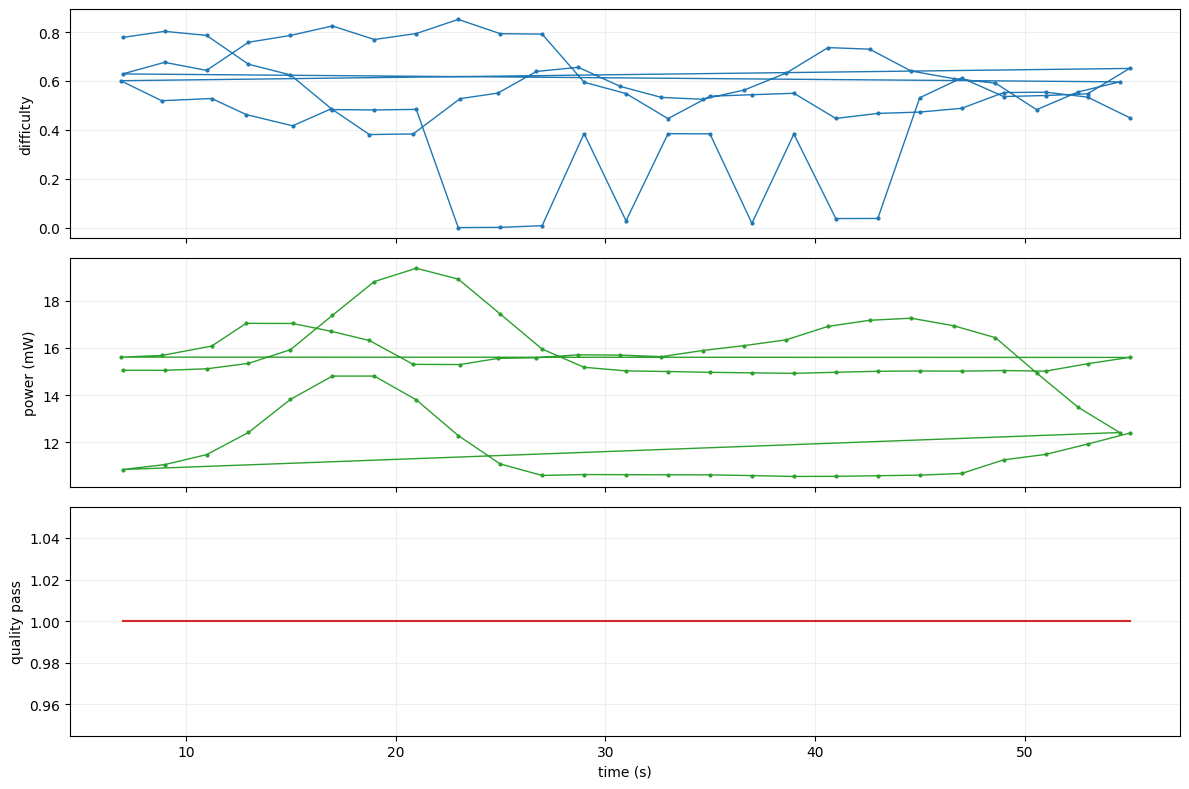

{'num_files': 18, 'total_rows_raw': 27268, 'total_windows': 451, 'overall_quality_pass_ratio': 0.8181818181818182, 'profiles': ['100sps_med', '25sps_low', '50sps_med']}


In [10]:
# Timeline quick-look cho 1 run tiêu biểu

VIEW_PROFILE = "50sps_med"

VIEW_CONDITION = "good"



candidate = quality_df[(quality_df["profile_name"] == VIEW_PROFILE) & (quality_df["condition"] == VIEW_CONDITION)].copy()

if len(candidate) == 0:

    candidate = quality_df.copy()



view_df = candidate.sort_values(["file_name", "window_start_s"]).copy().reset_index(drop=True)

view_df["window_mid_s"] = (view_df["window_start_s"] + view_df["window_end_s"]) / 2.0



fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(view_df["window_mid_s"], view_df["difficulty_score_norm"], marker="o", markersize=2, linewidth=1)

axes[0].set_ylabel("difficulty")

axes[0].grid(alpha=0.2)



axes[1].plot(view_df["window_mid_s"], view_df["power_mw_mean"], marker="o", markersize=2, linewidth=1, color="tab:green")

axes[1].set_ylabel("power (mW)")

axes[1].grid(alpha=0.2)



axes[2].step(view_df["window_mid_s"], view_df["quality_pass"].astype(int), where="mid", color="tab:red")

axes[2].set_ylabel("quality pass")

axes[2].set_xlabel("time (s)")

axes[2].grid(alpha=0.2)



plt.tight_layout()

plt.show()



summary = {

    "num_files": int(file_stats_df.shape[0]),

    "total_rows_raw": int(len(raw_df)),

    "total_windows": int(len(feature_df)),

    "overall_quality_pass_ratio": float(quality_df["quality_pass"].mean()),

    "profiles": sorted(quality_df["profile_name"].unique().tolist()),

}

print(summary)

In [11]:
# Policy v1 analysis (chỉ giữ 3 profile chính, loại 100sps_high)
POLICY_PROFILES = ["25sps_low", "50sps_med", "100sps_med"]
policy_df = quality_df[quality_df["profile_name"].isin(POLICY_PROFILES)].copy()

print("=== Policy map (window-level) ===")
policy_map_df = policy_df.groupby(["profile_name", "condition"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
    ir_ptp_mean=("ir_raw_ptp", "mean"),
).reset_index().sort_values(["profile_name", "condition"])
display(policy_map_df)

# Run-level stats để báo cáo mean ± std theo nhiều run
run_level_df = policy_df.groupby(["profile_name", "condition", "run_idx", "file_name"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
).reset_index()

report_stats_df = run_level_df.groupby(["profile_name", "condition"]).agg(
    n_runs=("run_idx", "nunique"),
    windows_mean=("windows", "mean"),
    quality_pass_ratio_mean=("quality_pass_ratio", "mean"),
    quality_pass_ratio_std=("quality_pass_ratio", "std"),
    avg_power_mw_mean=("avg_power_mw", "mean"),
    avg_power_mw_std=("avg_power_mw", "std"),
    difficulty_mean_mean=("difficulty_mean", "mean"),
    difficulty_mean_std=("difficulty_mean", "std"),
).reset_index().sort_values(["profile_name", "condition"])

print("\n=== Report table (mean ± std over runs) ===")
display(report_stats_df)

decision3_df = policy_map_df[[
    "profile_name", "condition", "quality_pass_ratio", "avg_power_mw", "difficulty_mean", "windows"
]].copy()

good_rank3 = decision3_df[decision3_df["condition"] == "good"].sort_values(
    ["quality_pass_ratio", "avg_power_mw", "difficulty_mean"],
    ascending=[False, True, True]
).reset_index(drop=True)

bad_rank3 = decision3_df[decision3_df["condition"] == "bad"].sort_values(
    ["quality_pass_ratio", "difficulty_mean", "avg_power_mw"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== Good ranking (3 profiles) ===")
display(good_rank3)

print("=== Bad robustness ranking (3 profiles) ===")
display(bad_rank3)

def suggest_policy_v1(row):
    if row["condition"] == "good":
        if row["profile_name"] == "50sps_med":
            return "default_profile"
        if row["profile_name"] == "25sps_low":
            return "candidate_low_power_only_if_stable"
        if row["profile_name"] == "100sps_med":
            return "candidate_high_fidelity_when_hard"
    return "reference"

policy_suggestion_df = decision3_df.copy()
policy_suggestion_df["suggestion"] = policy_suggestion_df.apply(suggest_policy_v1, axis=1)

print("=== Policy v1 suggestion ===")
display(policy_suggestion_df.sort_values(["condition", "profile_name"]).reset_index(drop=True))

=== Policy map (window-level) ===


,profile_name,condition,windows,quality_pass_ratio,avg_power_mw,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,76,0.842105,19.060457,0.604189,0.212097,127240.197368
1,100sps_med,good,75,1.000000,19.612429,0.538545,0.719870,5078.440000
2,25sps_low,bad,75,0.853333,13.711025,0.650646,0.235361,36204.853333
3,25sps_low,good,75,0.333333,17.526769,0.653504,0.673621,700.853333
4,50sps_med,bad,75,0.880000,13.462131,0.691279,0.253756,82160.226667
5,50sps_med,good,75,1.000000,14.435346,0.528127,0.715526,2856.693333



=== Report table (mean ± std over runs) ===


,profile_name,condition,n_runs,windows_mean,quality_pass_ratio_mean,quality_pass_ratio_std,avg_power_mw_mean,avg_power_mw_std,difficulty_mean_mean,difficulty_mean_std
0,100sps_med,bad,3,25.333333,0.842051,0.040157,19.057209,0.580976,0.604524,0.027312
1,100sps_med,good,3,25.000000,1.000000,0.000000,19.612429,0.596511,0.538545,0.228198
2,25sps_low,bad,3,25.000000,0.853333,0.046188,13.711025,2.685419,0.650646,0.024930
3,25sps_low,good,3,25.000000,0.333333,0.446019,17.526769,0.858010,0.653504,0.069539
4,50sps_med,bad,3,25.000000,0.880000,0.040000,13.462131,1.948018,0.691279,0.007676
5,50sps_med,good,3,25.000000,1.000000,0.000000,14.435346,2.455381,0.528127,0.109082



=== Good ranking (3 profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,50sps_med,good,1.000000,14.435346,0.528127,75
1,100sps_med,good,1.000000,19.612429,0.538545,75
2,25sps_low,good,0.333333,17.526769,0.653504,75


=== Bad robustness ranking (3 profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,50sps_med,bad,0.880000,13.462131,0.691279,75
1,25sps_low,bad,0.853333,13.711025,0.650646,75
2,100sps_med,bad,0.842105,19.060457,0.604189,76


=== Policy v1 suggestion ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows,suggestion
0,100sps_med,bad,0.842105,19.060457,0.604189,76,reference
1,25sps_low,bad,0.853333,13.711025,0.650646,75,reference
2,50sps_med,bad,0.880000,13.462131,0.691279,75,reference
3,100sps_med,good,1.000000,19.612429,0.538545,75,candidate_high_fidelity_when_hard
4,25sps_low,good,0.333333,17.526769,0.653504,75,candidate_low_power_only_if_stable
5,50sps_med,good,1.000000,14.435346,0.528127,75,default_profile


In [12]:
# Scheduler simulation v1 (offline, data-driven from real logs)
BASE_PROFILE = "50sps_med"
LOW_PROFILE = "25sps_low"
HIGH_PROFILE = "100sps_med"
EASY_Q = 0.35
HARD_Q = 0.70
MIN_STABLE_WINDOWS = 3

sim_base = policy_df[(policy_df["profile_name"] == BASE_PROFILE)].copy()
sim_base = sim_base.sort_values(["condition", "file_name", "window_start_s"]).reset_index(drop=True)
assert len(sim_base) > 0, "Không có window từ 50sps_med để mô phỏng scheduler"

lookup = policy_df.groupby(["condition", "profile_name"]).agg(
    est_quality_pass=("quality_pass", "mean"),
    est_power_mw=("power_mw_mean", "mean"),
).reset_index()

lookup_q = {(r.condition, r.profile_name): float(r.est_quality_pass) for r in lookup.itertuples()}
lookup_p = {(r.condition, r.profile_name): float(r.est_power_mw) for r in lookup.itertuples()}

state = BASE_PROFILE
stable_count = 0
sim_rows = []

for r in sim_base.itertuples():
    cond = r.condition
    diff = float(r.difficulty_score_norm)
    qpass = bool(r.quality_pass)

    if (not qpass) or (diff >= HARD_Q):
        state = HIGH_PROFILE
        stable_count = 0
    elif diff <= EASY_Q and qpass:
        stable_count += 1
        if stable_count >= MIN_STABLE_WINDOWS:
            state = LOW_PROFILE
    else:
        state = BASE_PROFILE
        stable_count = 0

    sim_rows.append({
        "condition": cond,
        "file_name": r.file_name,
        "window_start_s": float(r.window_start_s),
        "driver_difficulty": diff,
        "driver_quality_pass": int(qpass),
        "selected_profile": state,
        "est_quality_pass": lookup_q.get((cond, state), np.nan),
        "est_power_mw": lookup_p.get((cond, state), np.nan),
    })

sim_df = pd.DataFrame(sim_rows)
sim_df["est_quality_pass"] = sim_df["est_quality_pass"].fillna(0.0)
sim_df["est_power_mw"] = sim_df["est_power_mw"].fillna(policy_df["power_mw_mean"].mean())

state_ratio = sim_df["selected_profile"].value_counts(normalize=True).rename("time_ratio").reset_index()
state_ratio.columns = ["selected_profile", "time_ratio"]

sim_summary = pd.DataFrame([{
    "windows": int(len(sim_df)),
    "estimated_quality_pass_ratio": float(sim_df["est_quality_pass"].mean()),
    "estimated_avg_power_mw": float(sim_df["est_power_mw"].mean()),
    "baseline_50sps_quality_pass_ratio": float(policy_df[policy_df["profile_name"] == BASE_PROFILE]["quality_pass"].mean()),
    "baseline_50sps_avg_power_mw": float(policy_df[policy_df["profile_name"] == BASE_PROFILE]["power_mw_mean"].mean()),
}])

print("=== Scheduler v1 state ratio ===")
display(state_ratio)

print("=== Scheduler v1 estimated summary ===")
display(sim_summary)

=== Scheduler v1 state ratio ===


,selected_profile,time_ratio
0,50sps_med,0.660000
1,100sps_med,0.333333
2,25sps_low,0.006667


=== Scheduler v1 estimated summary ===


,windows,estimated_quality_pass_ratio,estimated_avg_power_mw,baseline_50sps_quality_pass_ratio,baseline_50sps_avg_power_mw
0,150,0.926208,15.798949,0.94,13.948739
